# Autoencoder with ACCESS-OM2

Autoencoder with ACCESS-OM2 Ocean Heat Content Data

This notebook trains an autoencoder on ocean heat content and surface heat flux data from the ACCESS-OM2 model using partial convolutions to handle land-masked regions.

In [1]:
# System and path handling
import sys
from pathlib import Path

# Data handling
import numpy as np
import pandas as pd
import xarray as xr

# PyEarthTools pipeline
import pyearthtools.data as petdata
from pyearthtools.data.transforms import TransformCollection
import pyearthtools.pipeline as petpipe
import pyearthtools.data.archive as arch

# Deep learning
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

# Visualization
import matplotlib.pyplot as plt

# Configure device and random seed
torch.manual_seed(42)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Source data and code directories
userbase = "/g/data/v46/txs156/"
repobase = "/home/156/txs156/uom/OM2-emulator/"

# Add the src directory to the Python path (relative to notebook location)
src_path = Path(repobase) / "src"
sys.path.insert(0, str(src_path))

# Import the ACCESS_OHC data accessor from om2_data_utils module
from om2_data_utils import ACCESS_OHC

# Import the PartialConv2d layer from om2_model_utils module
from om2_model_utils import PartialConv2d

In [2]:
normalisation_strategies = ["Global_in_time_and_space",  
                            "Spatial_over_all_times", "Spatial_per_month"]
#                            per grid over months (climatology)



## Setup PyEarthTools data accessor and pipeline

In [3]:
# Setup the data accessor and pipeline
ACCESS_OHC_accessor = ACCESS_OHC(
    ["area_t", "ocean_heat_content_2d", "total_surface_heat_flx"],
    root=userbase + "OM2-emulator/data/",
)

# Keep one explicit time window so all normalisation paths are directly comparable.
normalisation_start = '2000-01'
normalisation_end = '2018-12'
normalisation_interval = '1 month'
normalisation_window = dict(start=normalisation_start, end=normalisation_end, interval=normalisation_interval)
normalised_variables = ["ocean_heat_content_2d", "total_surface_heat_flx"]

# -----------------------------------------------------------------------------
# Build normalisation stats explicitly from ocean-only values (land -> NaN),
# then use skipna reductions so land never contributes to mean/std.
# -----------------------------------------------------------------------------
ds_stats = xr.open_dataset(userbase + "OM2-emulator/data/1deg_ocean_heat_emulator_data.nc")
ds_stats = ds_stats.sel(time=slice(normalisation_start, normalisation_end))
ds_stats = ds_stats[normalised_variables]

# Keep mask derivation consistent with training/diagnostics convention:
# 1 = ocean, 0 = land.
mask_xr = xr.where(np.isnan(ds_stats.total_surface_heat_flx.isel(time=0)), 0, 1)
masked_stats = ds_stats.where(mask_xr == 1)

# Align spatial dimension names with the pipeline (Sort uses latitude/longitude).
rename_map = {}
if "yt_ocean" in masked_stats.dims:
    rename_map["yt_ocean"] = "latitude"
if "xt_ocean" in masked_stats.dims:
    rename_map["xt_ocean"] = "longitude"
if rename_map:
    masked_stats = masked_stats.rename(rename_map)

# 1) Global stats (scalar per variable)
global_mean_stats = masked_stats.mean(dim=("time", "latitude", "longitude"), skipna=True)
global_std_stats = masked_stats.std(dim=("time", "latitude", "longitude"), skipna=True)

# 2) Spatial stats (per-gridcell over all times)
spatial_mean_stats = masked_stats.mean(dim="time", skipna=True)
spatial_std_stats = masked_stats.std(dim="time", skipna=True)

# 3) Spatial climatology
spatial_mean_stats = masked_stats.groupby('time.month').mean(dim="month", skipna=True)
spatial_std_stats = masked_stats.groupby('time.month').std(dim="month", skipna=True)

# Tile the climatology


# Prevent divide-by-zero in fully masked/constant regions.
eps = 1e-6
global_std_stats = global_std_stats.where(global_std_stats > eps, eps)
spatial_std_stats = spatial_std_stats.where(spatial_std_stats > eps, eps)

# Keep only model variables for consistency.
keep_vars = [v for v in normalised_variables if v in global_mean_stats.data_vars]
global_mean_stats = global_mean_stats[keep_vars]
global_std_stats = global_std_stats[keep_vars]
spatial_mean_stats = spatial_mean_stats[keep_vars]
spatial_std_stats = spatial_std_stats[keep_vars]

# Drop curvilinear geolocation coords from stats datasets so they match the
# pipeline structure after Drop(['geolat_t', 'geolon_t']) and avoid alignment
# side effects during xarray normalisation -> ToNumpy conversion.
for _ds_name in ["global_mean_stats", "global_std_stats", "spatial_mean_stats", "spatial_std_stats"]:
    _ds = locals()[_ds_name]
    _drop_coords = [c for c in ["geolat_t", "geolon_t"] if c in _ds.coords or c in _ds.data_vars]
    if _drop_coords:
        _ds = _ds.drop_vars(_drop_coords, errors='ignore')
    locals()[_ds_name] = _ds

# Define pipeline normalisation operations for each strategy.
pipelines_normed = [
    petpipe.operations.xarray.normalisation.Evaluated(
        normalisation_eval="(sample - mean) / deviation",
        unnormalisation_eval="(sample * deviation) + mean",
        mean=global_mean_stats,
        deviation=global_std_stats,
    ),
    petpipe.operations.xarray.normalisation.Evaluated(
        normalisation_eval="(sample - mean) / deviation",
        unnormalisation_eval="(sample * deviation) + mean",
        mean=spatial_mean_stats,
        deviation=spatial_std_stats,
    ),
]



In [5]:
# Build one pipeline per normalisation strategy and retrieve one sample from each.
# This now uses full PET pipeline normalisation directly.
full_grid_over_time = []
pipelines = []
ipipe = []
n = []

for i, norm_op in enumerate(pipelines_normed):
    print(i, normalisation_strategies[i])

    pipelines.append(petpipe.Pipeline(
        ACCESS_OHC_accessor,
        petdata.transforms.coordinates.Drop(['geolat_t', 'geolon_t']),
        petdata.transforms.variables.Drop(['area_t']),
        petpipe.operations.xarray.Sort(order=['time', 'latitude', 'longitude']),
        norm_op,
        petpipe.operations.xarray.values.FillNan(0),
        petpipe.operations.xarray.conversion.ToNumpy(),
        petpipe.operations.numpy.reshape.Rearrange('c t h w -> t c h w'),
        iterator=petpipe.iterators.DateRange(normalisation_start, normalisation_end, interval=normalisation_interval),
    ))

    full_grid_over_time.append(pipelines[i])
    ip_i = iter(pipelines[i])
    ipipe.append(ip_i)
    sample_i = next(ip_i)
    n.append(sample_i)
    print('sample shape:', sample_i.shape)


0 Global_in_time_and_space
sample shape: (1, 2, 300, 360)
1 Spatial_over_all_times
sample shape: (1, 2, 300, 360)


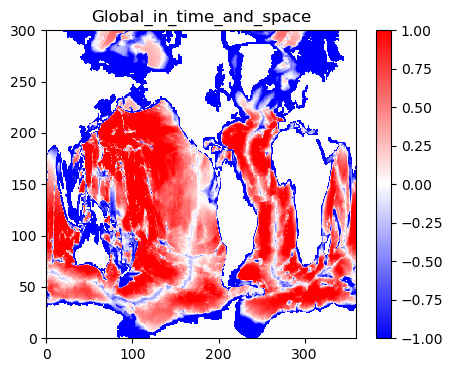

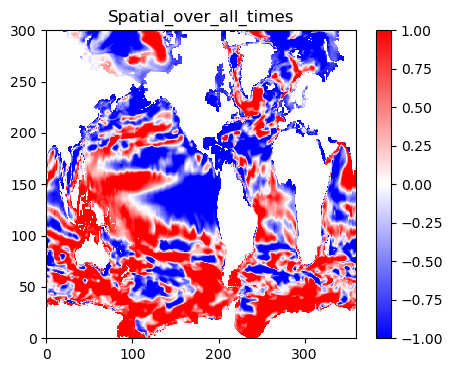

In [6]:
# Quick visual check of first variable at first time step for each strategy.
for i, strategy in enumerate(normalisation_strategies):
    plt.figure(figsize=(5, 4))
    plt.pcolor(n[i][0, 0, :, :], vmin=-1, vmax=1, cmap=plt.cm.bwr)
    plt.colorbar()
    plt.title(strategy)
    plt.show()



In [7]:
# Keep mask derivation from source data so land points stay excluded from metrics/loss.
ds_mask = xr.open_dataset(userbase + "OM2-emulator/data/1deg_ocean_heat_emulator_data.nc")
mask_xr = xr.where(np.isnan(ds_mask.total_surface_heat_flx.isel(time=0)), 0, 1)
mask = mask_xr.values

## Do some checks - input data and partial convolutions

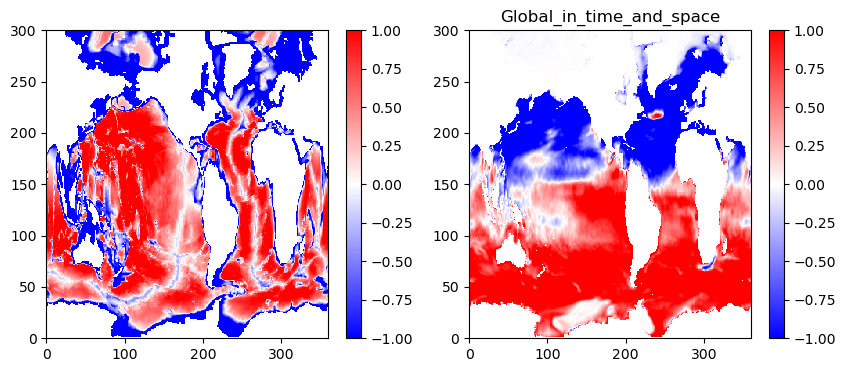

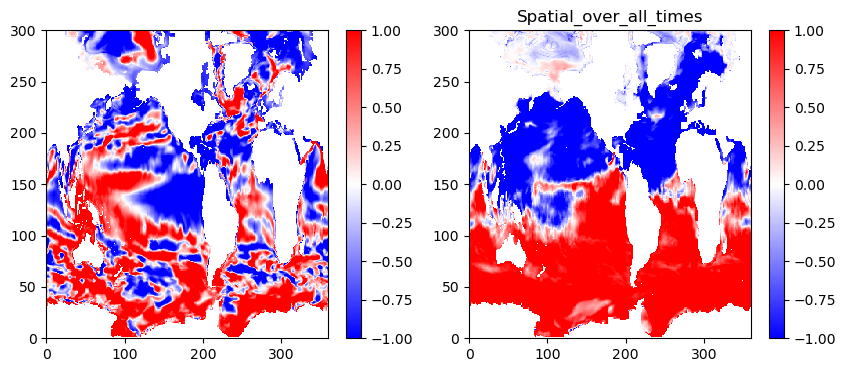

In [8]:
# Quick check to see if things look reasonable:
for i, norm_op in enumerate(pipelines_normed):
    QNET = np.where(mask, n[i][0,1,:,:], np.nan)
    OHC = np.where(mask, n[i][0,0,:,:], np.nan)
    
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(10,4))
    
    pcm0 = axes[0].pcolormesh(OHC, vmin=-1, vmax=1, cmap = plt.cm.bwr)
    pcm1 = axes[1].pcolormesh(QNET, vmin=-1, vmax=1, cmap = plt.cm.bwr)
    plt.title(normalisation_strategies[i])

    fig.colorbar(pcm0, ax=axes[0])
    fig.colorbar(pcm1, ax=axes[1])
    
    plt.show()

Input shape: torch.Size([1, 1, 300, 360])
Input Mask shape: torch.Size([1, 1, 300, 360])
Output shape: torch.Size([1, 1, 150, 180])
New Mask shape: torch.Size([1, 1, 150, 180])
Original valid fraction: 0.6463796296296296
New valid fraction: 0.6898888945579529


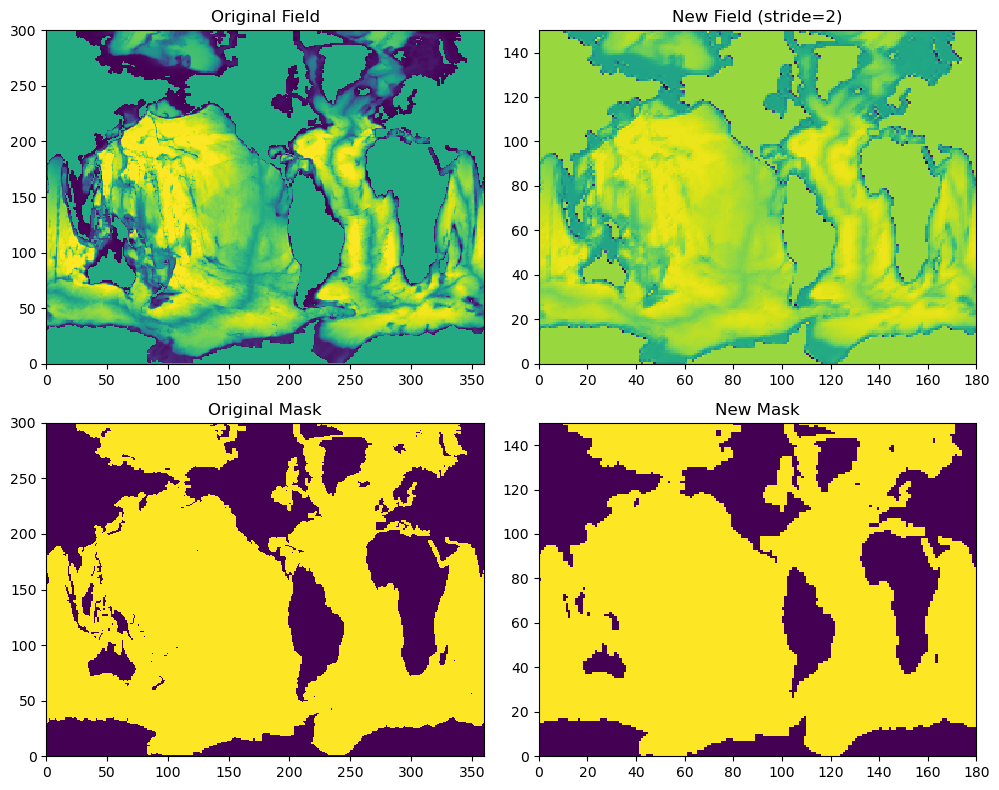

In [9]:
# Test Partial Convolution:
# convert to tensors
field = n[0][0,0,:,:]  # Take the first variable (OHC) for the first time step
x = torch.tensor(field, dtype=torch.float32)
mask_t = torch.tensor(mask, dtype=torch.float32)  # Explicit .values to extract numpy array
x = x.unsqueeze(0).unsqueeze(0)
mask_t = mask_t.unsqueeze(0).unsqueeze(0)

# Do an example convolution:
layer = PartialConv2d(in_ch=1,out_ch=1,kernel_size=3,stride=2,padding=1)
out, new_mask = layer(x, mask_t)

print("Input shape:", x.shape)
print("Input Mask shape:", mask_t.shape)
print("Output shape:", out.shape)
print("New Mask shape:", new_mask.shape)

# Convert tensors → numpy
new_field = out.detach().squeeze().numpy()
new_mask  = new_mask.detach().squeeze().numpy()

# Fractions covered by ocean:
print("Original valid fraction:", mask.mean().item())
print("New valid fraction:", new_mask.mean().item())

# Plot the results:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
im0 = axes[0,0].pcolormesh(field)
axes[0,0].set_title("Original Field")
im1 = axes[1,0].pcolormesh(mask)
axes[1,0].set_title("Original Mask")
im2 = axes[0,1].pcolormesh(new_field)
axes[0,1].set_title("New Field (stride=2)")
im3 = axes[1,1].pcolormesh(new_mask)
axes[1,1].set_title("New Mask")
plt.tight_layout()
plt.show()

## Define the model

In [10]:
class AutoEncoder(nn.Module):

    def __init__(self,
                 input_channel_count=2,
                 output_channel_count=2):

        super(AutoEncoder, self).__init__()

        # ---------- Encoder ----------
        self.enc1 = PartialConv2d(input_channel_count, 16, kernel_size=4, stride=2, padding=1)
        self.enc2 = PartialConv2d(16, 32, kernel_size=3, stride=2, padding=1)
        self.enc3 = PartialConv2d(32, 64, kernel_size=7, stride=1, padding=3)

        # ---------- Decoder ----------
        self.dec1 = PartialConv2d(64, 32, kernel_size=7, stride=1, padding=3)
        self.dec2 = PartialConv2d(32, 16, kernel_size=3, stride=1, padding=1)
        self.dec3 = PartialConv2d(16, output_channel_count, kernel_size=4, stride=1, padding=2)

        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()
    
    def encode(self, x, mask):
        """Encoder: returns latent representation and updated mask"""
        x, mask = self.enc1(x, mask)
        x = self.relu(x)
        x, mask = self.enc2(x, mask)
        x = self.relu(x)
        x, mask = self.enc3(x, mask)
        x = self.relu(x)
        return x, mask
    
    def decode(self, x, mask):
        """Decoder: takes latent representation and reconstructs output"""
        # upsample 1
        x = F.interpolate(x, scale_factor=2, mode="bilinear", align_corners=False)
        mask = F.interpolate(mask, scale_factor=2, mode="nearest")

        x, mask = self.dec1(x, mask)
        x = self.relu(x)

        # upsample 2
        x = F.interpolate(x, scale_factor=2, mode="bilinear", align_corners=False)
        mask = F.interpolate(mask, scale_factor=2, mode="nearest")

        x, mask = self.dec2(x, mask)
        x = self.relu(x)

        # final conv
        x, mask = self.dec3(x, mask)
        reconstructed = self.sigmoid(x)
        
        return reconstructed, mask
    
    def forward(self, x, mask):
        # Store input size for later
        input_h, input_w = x.shape[2], x.shape[3]

        # Encoder
        latent, latent_mask = self.encode(x, mask)

        # Decoder
        reconstructed, final_mask = self.decode(latent, latent_mask)
        
        # Crop to match input size (handles rounding errors from upsampling)
        reconstructed = reconstructed[:, :, :input_h, :input_w]

        return reconstructed



## Initialize model and prepare data for training

In [11]:
# Initialize a lightweight model instance for quick smoke tests in the next cell.
# Full training models are created per normalisation mode in the training cell below.
model = AutoEncoder(input_channel_count=n[0].shape[1], output_channel_count=n[0].shape[1]).to(device)

# Keep criterion declaration for consistency with previous notebook workflow.
criterion = nn.L1Loss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

x = []

for i, norm_op in enumerate(pipelines_normed):
    # Convert numpy -> tensor for one reference sample used in normalisation diagnostics.
    x.append(torch.from_numpy(n[i]).float().to(device))

# Prepare mask with shape [1, 1, H, W] so it broadcasts over [T, C, H, W].
# We use ocean mask values so land points are excluded from normalisation/loss.
mask_t = torch.tensor(np.ones_like(mask), dtype=torch.float32).unsqueeze(0).unsqueeze(0).float().to(device) # zero mask for testing



Input shape: torch.Size([1, 2, 300, 360])
Mask shape: torch.Size([1, 1, 300, 360])
Prediction shape: torch.Size([1, 2, 300, 360])


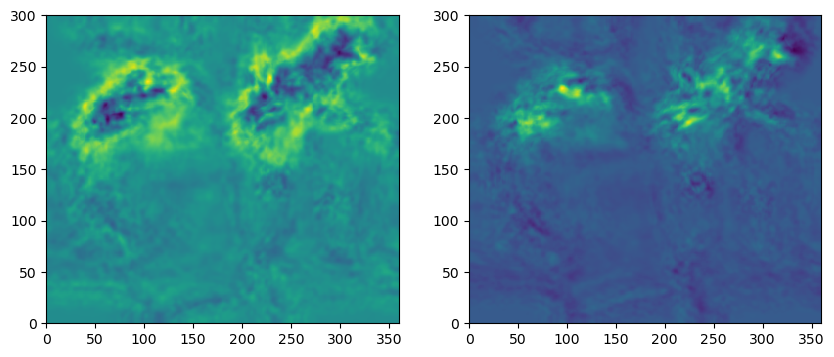

Input shape: torch.Size([1, 2, 300, 360])
Mask shape: torch.Size([1, 1, 300, 360])
Prediction shape: torch.Size([1, 2, 300, 360])


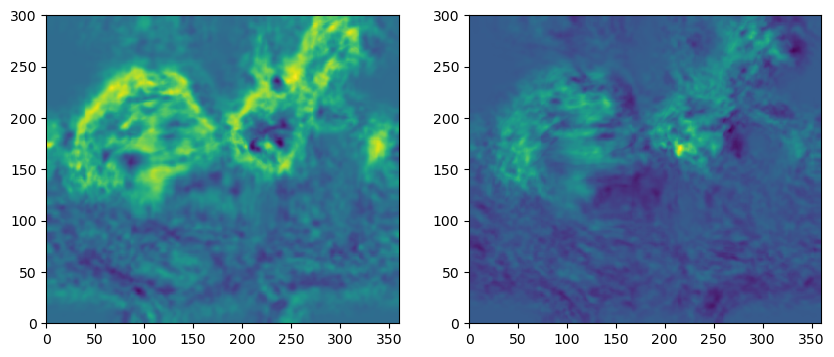

In [12]:
# Test model forward pass with untrained weights:
for i, norm_op in enumerate(pipelines_normed):

    prediction = model(x[i], mask_t)
    print("Input shape:", x[i].shape)
    print("Mask shape:", mask_t.shape)
    print("Prediction shape:", prediction.shape)
    
    image_numpy_for_display = prediction.to('cpu').detach().numpy()
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].pcolormesh(image_numpy_for_display[0][0])
    axes[1].pcolormesh(image_numpy_for_display[0][1])
    plt.show()

## Training loop

In [13]:
%%time


def train(x_in, mask_t, debug=True, num_epochs=1, max_samples=10, print_per=20):

    # Training loop
    avg_losses = []

    for epoch in range(num_epochs):
        total_loss = 0.0
        epoch_step_count = min(max_samples, x_in.shape[0])

        for epoch_samples in range(1, epoch_step_count + 1):
            if epoch_samples % print_per == 0:
                print(epoch_samples, flush=True)

            if debug:
                print(epoch_samples)
                print("Input")
                print(x_in)

            optimizer.zero_grad()

            # Forward pass
            y = model(x_in, mask_t)

            # Compute masked loss
            diff = torch.abs(y - x_in)
            loss = (diff * mask_t).sum() / mask_t.sum()

            if debug:
                print("prediction")
                print(y)
                print("loss")
                print(loss)

            # Backward pass and optimize
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / epoch_step_count
        avg_losses.append(avg_loss)
        print(f'Epoch [{epoch+1}/{num_epochs}], Average Loss: {avg_loss:.4f}', flush=True)

    return avg_losses


for i, norm_op in enumerate(pipelines_normed):
    # print("###########", normalisation_strategies[i], "###############")
    train(x[i], mask_t, debug=False, num_epochs=100, max_samples=15 * 1000, print_per=500)



Epoch [1/100], Average Loss: 1.4823
Epoch [2/100], Average Loss: 1.4808
Epoch [3/100], Average Loss: 1.4790
Epoch [4/100], Average Loss: 1.4769
Epoch [5/100], Average Loss: 1.4741
Epoch [6/100], Average Loss: 1.4707
Epoch [7/100], Average Loss: 1.4665
Epoch [8/100], Average Loss: 1.4612
Epoch [9/100], Average Loss: 1.4547
Epoch [10/100], Average Loss: 1.4468
Epoch [11/100], Average Loss: 1.4374
Epoch [12/100], Average Loss: 1.4261
Epoch [13/100], Average Loss: 1.4129
Epoch [14/100], Average Loss: 1.3978
Epoch [15/100], Average Loss: 1.3806
Epoch [16/100], Average Loss: 1.3615
Epoch [17/100], Average Loss: 1.3406
Epoch [18/100], Average Loss: 1.3183
Epoch [19/100], Average Loss: 1.2950
Epoch [20/100], Average Loss: 1.2713
Epoch [21/100], Average Loss: 1.2478
Epoch [22/100], Average Loss: 1.2253
Epoch [23/100], Average Loss: 1.2045
Epoch [24/100], Average Loss: 1.1858
Epoch [25/100], Average Loss: 1.1696
Epoch [26/100], Average Loss: 1.1559
Epoch [27/100], Average Loss: 1.1446
Epoch [28/

## Compute final prediction

In [14]:
prediction = model(x[i], mask_t)
pred_np = prediction.detach().cpu().numpy()

# Build physical-space predictions for all normalisation modes.
mean_stats_by_mode = [global_mean_stats, spatial_mean_stats]
prediction_phys_ds = []

def _resolve_spatial_layout(sample_h, sample_w):
    ref_var = normalised_variables[0]

    # Prefer spatial stats because global stats can be scalar (() dims).
    if ref_var in spatial_mean_stats.data_vars:
        dims = [d for d in spatial_mean_stats[ref_var].dims if d != "time"]
        if len(dims) >= 2:
            y_dim, x_dim = dims[-2], dims[-1]
            y_vals = spatial_mean_stats.coords[y_dim].values if y_dim in spatial_mean_stats.coords else np.arange(sample_h)
            x_vals = spatial_mean_stats.coords[x_dim].values if x_dim in spatial_mean_stats.coords else np.arange(sample_w)
            return y_dim, x_dim, y_vals, x_vals

    # Fallback: generic labelled dimensions.
    return "latitude", "longitude", np.arange(sample_h), np.arange(sample_w)

sample_h, sample_w = pred_np.shape[2], pred_np.shape[3]
y_dim, x_dim, y_vals, x_vals = _resolve_spatial_layout(sample_h, sample_w)

for mode_idx, norm_op in enumerate(pipelines_normed):
    pred_ds_mode = xr.Dataset(
        {
            v: ((y_dim, x_dim), pred_np[0, j, :, :])
            for j, v in enumerate(normalised_variables)
        },
        coords={
            y_dim: y_vals,
            x_dim: x_vals,
        },
    )

    prediction_phys_ds.append(norm_op.undo(pred_ds_mode))

# Backward-compatible aliases
prediction_phys_ds_selected = prediction_phys_ds[i]
pred_ds = pred_ds_mode





In [15]:
# Build mode-wise diagnostics artefacts used by latent/RMSE/plot cells.
import numpy as np
import xarray as xr
import torch

NORMALISATION_MODES = list(normalisation_strategies)
selected_mode_for_detail = NORMALISATION_MODES[0]

mean_stats_by_mode = [global_mean_stats, spatial_mean_stats]

def _resolve_spatial_layout(sample_h, sample_w):
    ref_var = normalised_variables[0]

    # Prefer spatial stats because global stats can be scalar (() dims).
    if ref_var in spatial_mean_stats.data_vars:
        dims = [d for d in spatial_mean_stats[ref_var].dims if d != "time"]
        if len(dims) >= 2:
            y_dim, x_dim = dims[-2], dims[-1]
            y_vals = spatial_mean_stats.coords[y_dim].values if y_dim in spatial_mean_stats.coords else np.arange(sample_h)
            x_vals = spatial_mean_stats.coords[x_dim].values if x_dim in spatial_mean_stats.coords else np.arange(sample_w)
            return y_dim, x_dim, y_vals, x_vals

    # Fallback: generic labelled dimensions.
    return "latitude", "longitude", np.arange(sample_h), np.arange(sample_w)

def _tensor_to_dataset(sample_np, mode_idx):
    sample_h, sample_w = sample_np.shape[2], sample_np.shape[3]
    y_dim, x_dim, y_vals, x_vals = _resolve_spatial_layout(sample_h, sample_w)

    ds = xr.Dataset(
        {
            v: ((y_dim, x_dim), sample_np[0, j, :, :])
            for j, v in enumerate(normalised_variables)
        },
        coords={
            y_dim: y_vals,
            x_dim: x_vals,
        },
    )
    return ds

results_by_mode = {}
prediction_display_by_mode = {}
input_display_by_mode = {}

_was_training = model.training
model.eval()
with torch.no_grad():
    for mode_idx, mode in enumerate(NORMALISATION_MODES):
        x_mode = x[mode_idx]

        latent, _ = model.encode(x_mode, mask_t)
        prediction_mode = model(x_mode, mask_t)

        pred_np = prediction_mode.detach().cpu().numpy()
        input_np = x_mode.detach().cpu().numpy()

        pred_ds_mode = _tensor_to_dataset(pred_np, mode_idx)
        input_ds_mode = _tensor_to_dataset(input_np, mode_idx)

        pred_phys_ds_mode = pipelines_normed[mode_idx].undo(pred_ds_mode)
        input_phys_ds_mode = pipelines_normed[mode_idx].undo(input_ds_mode)

        pred_display = np.stack([pred_phys_ds_mode[v].values for v in normalised_variables], axis=0)[np.newaxis, ...]
        input_display = np.stack([input_phys_ds_mode[v].values for v in normalised_variables], axis=0)[np.newaxis, ...]

        prediction_display_by_mode[mode] = pred_display
        input_display_by_mode[mode] = input_display

        results_by_mode[mode] = {
            "latent": latent.detach().cpu().numpy()[0],  # (C_latent, H_latent, W_latent)
            "prediction": pred_display,
            "input": input_display,
        }

if _was_training:
    model.train()





In [16]:
# Compare per-mode "actual" only over ocean (sanity check).
# If masking/undo are consistent, these differences should be near zero over ocean.

ocean_mask = mask.astype(bool)
reference_mode = NORMALISATION_MODES[0]
reference_actual = input_display_by_mode[reference_mode]

print(f"Reference mode: {reference_mode}")

for mode in NORMALISATION_MODES:
    actual = input_display_by_mode[mode]
    print(f"\nMode: {mode}")

    for ch, var_name in enumerate(normalised_variables):
        diff = np.where(ocean_mask, actual[0, ch] - reference_actual[0, ch], np.nan)

        max_abs = float(np.nanmax(np.abs(diff)))
        mean_abs = float(np.nanmean(np.abs(diff)))
        rmse = float(np.sqrt(np.nanmean(diff**2)))

        print(
            f"  {var_name}: max|Δ|={max_abs:.6e}, mean|Δ|={mean_abs:.6e}, RMSE={rmse:.6e}"
        )



Reference mode: Global_in_time_and_space

Mode: Global_in_time_and_space
  ocean_heat_content_2d: max|Δ|=0.000000e+00, mean|Δ|=0.000000e+00, RMSE=0.000000e+00
  total_surface_heat_flx: max|Δ|=0.000000e+00, mean|Δ|=0.000000e+00, RMSE=0.000000e+00

Mode: Spatial_over_all_times
  ocean_heat_content_2d: max|Δ|=1.310720e+05, mean|Δ|=1.366333e+04, RMSE=3.613567e+04
  total_surface_heat_flx: max|Δ|=6.103516e-05, mean|Δ|=1.879143e-06, RMSE=4.466812e-06


## 
Diagnostics

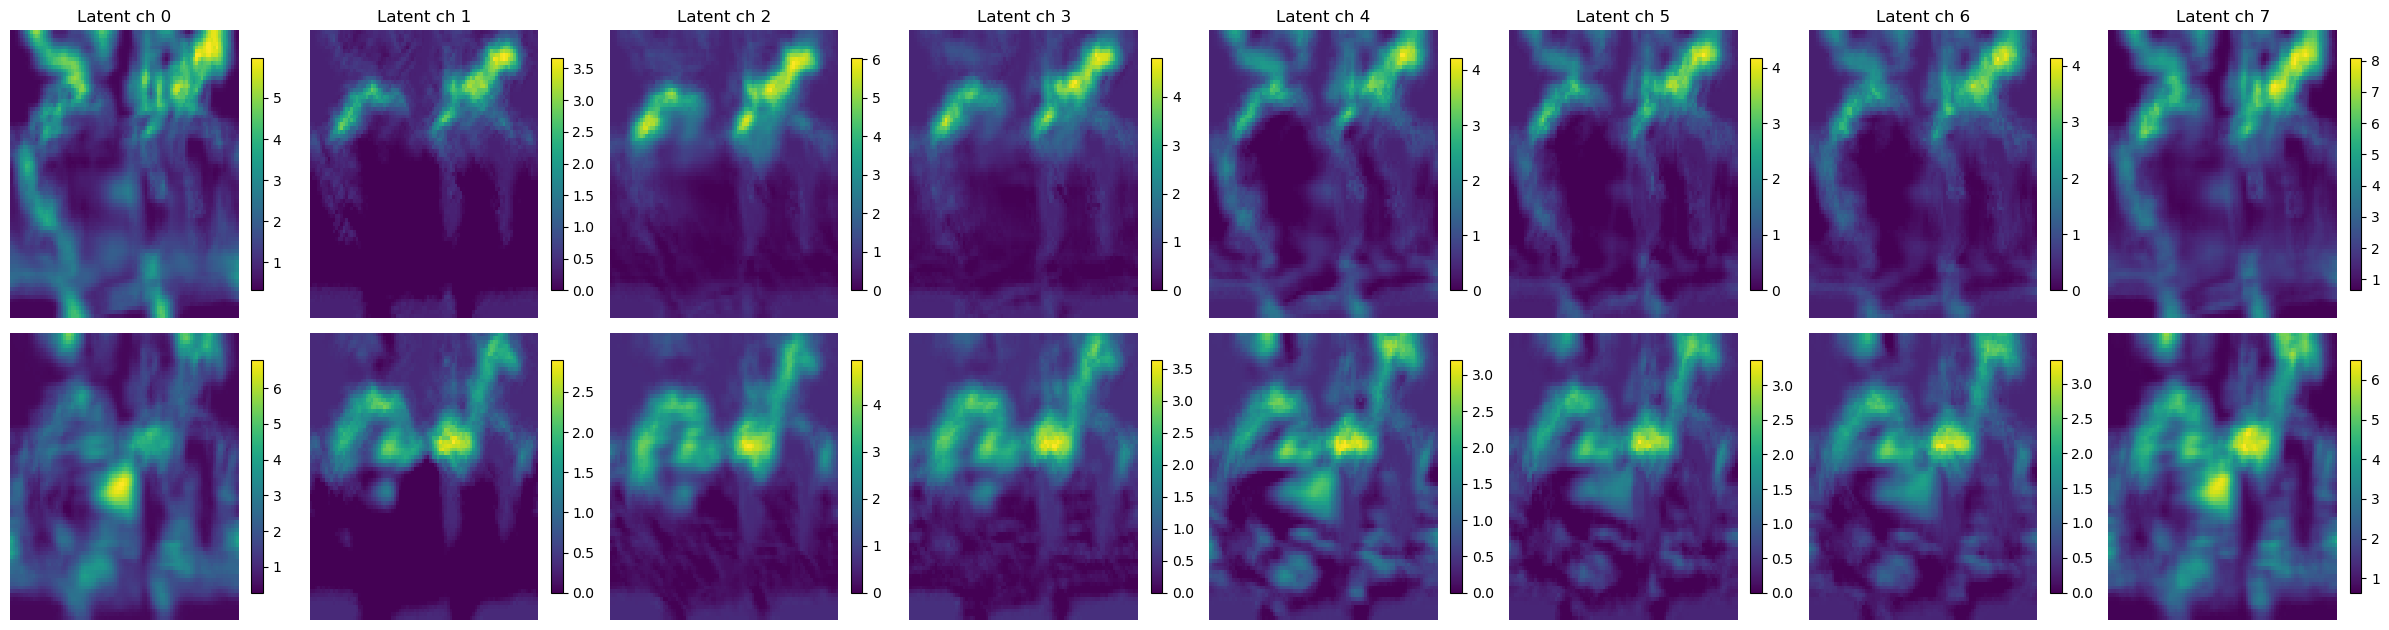

In [17]:
## Inspect Latent Space (all normalisation modes)

# Compare latent channels mode-by-mode on the same reference sample.
n_latent_show = min(8, min(results_by_mode[mode]["latent"].shape[0] for mode in NORMALISATION_MODES))

fig, axs = plt.subplots(len(NORMALISATION_MODES), n_latent_show, figsize=(3 * n_latent_show, 3.2 * len(NORMALISATION_MODES)))

# Normalise axis handling for the single-row edge case.
if len(NORMALISATION_MODES) == 1:
    axs = np.expand_dims(axs, axis=0)

for row, mode in enumerate(NORMALISATION_MODES):
    z = results_by_mode[mode]["latent"]  # (C_latent, H_latent, W_latent)
    for col in range(n_latent_show):
        ax = axs[row, col]
        im = ax.pcolormesh(z[col], cmap="viridis")
        ax.axis("off")
        if row == 0:
            ax.set_title(f"Latent ch {col}")
        if col == 0:
            ax.set_ylabel(mode)
        plt.colorbar(im, ax=ax, fraction=0.046)

plt.tight_layout()
plt.show()


In [18]:
## Compute RMSE (all normalisation modes)

# Shared area weights for fair spatially weighted RMSE across all modes.
ds = xr.open_dataset(userbase + "OM2-emulator/data/1deg_ocean_heat_emulator_data.nc")
area_t = ds.area_t.values.astype(np.float64)
area_weighted = area_t * mask

RMSE_by_mode = {}
for mode in NORMALISATION_MODES:
    pred = prediction_display_by_mode[mode]
    obs = input_display_by_mode[mode]

    # Channel convention in this notebook:
    # [0] = OHC, [1] = total_surface_heat_flx
    err_ohc = pred[0, 0] - obs[0, 0]
    err_sfx = pred[0, 1] - obs[0, 1]

    rmse_ohc = np.sqrt(np.nansum(err_ohc**2 * area_weighted) / np.nansum(area_weighted))
    rmse_sfx = np.sqrt(np.nansum(err_sfx**2 * area_weighted) / np.nansum(area_weighted))

    RMSE_by_mode[mode] = {
        "heat_flux": float(rmse_sfx),
        "ohc": float(rmse_ohc),
    }

    print(f"{mode} | RMSE heat_flux: {rmse_sfx:.6e}, RMSE OHC: {rmse_ohc:.6e}")

# Backward-compatible RMSE list for selected mode only.
RMSE = [
    RMSE_by_mode[selected_mode_for_detail]["heat_flux"],
    RMSE_by_mode[selected_mode_for_detail]["ohc"],
]


Global_in_time_and_space | RMSE heat_flux: 9.158664e+01, RMSE OHC: 1.424825e+12
Spatial_over_all_times | RMSE heat_flux: 7.699566e+01, RMSE OHC: 9.251029e+08


/g/data/v46/txs156/vscode-tmp/ipykernel_12461/3934509462.py:64: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


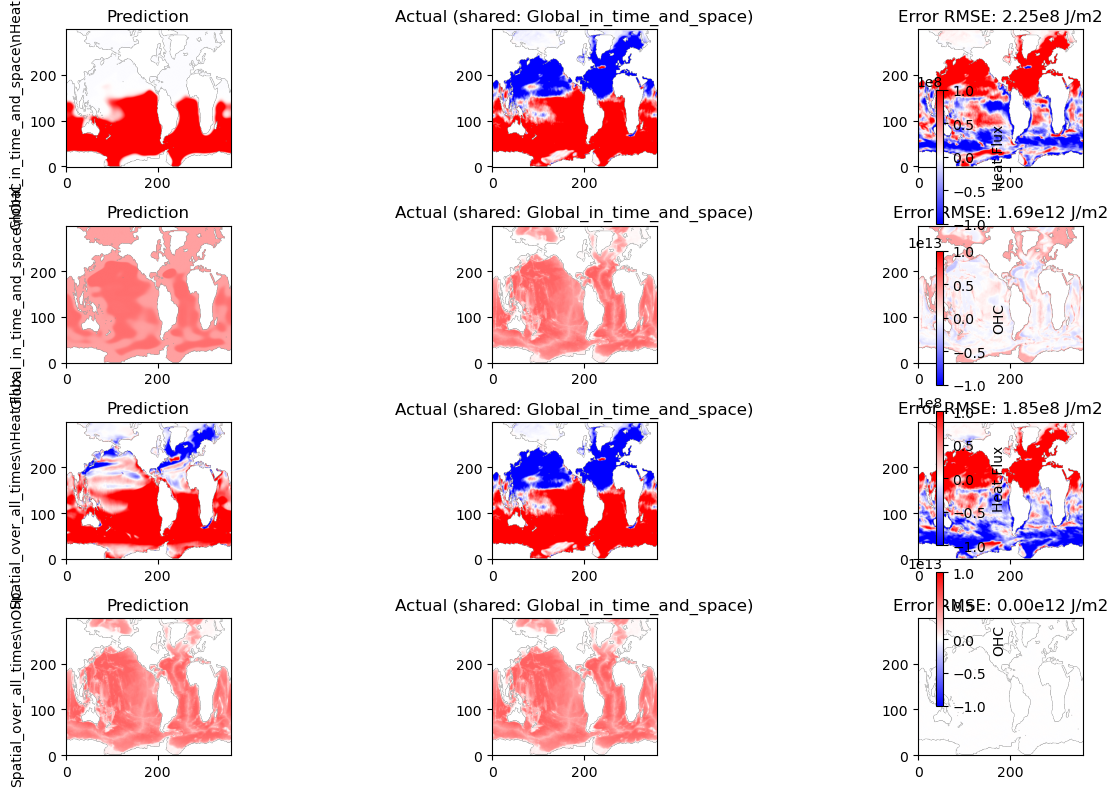

In [19]:
import matplotlib.pyplot as plt

# Spatial-map comparison for every normalisation mode:
# two rows per mode (heat flux and OHC), three columns (prediction, actual, error).
# Use one canonical actual field across modes to avoid mode-dependent undo artefacts.

num_modes = len(NORMALISATION_MODES)
fig, axes = plt.subplots(nrows=2 * num_modes, ncols=3, figsize=(14, 4 * num_modes))

# Ensure 2D indexing works even in edge cases.
if 2 * num_modes == 1:
    axes = np.expand_dims(axes, axis=0)

# Canonical actual: use first mode and keep it fixed across rows.
reference_mode = NORMALISATION_MODES[0]
obs_ref = input_display_by_mode[reference_mode]
ocean_mask = mask.astype(bool)

for mode_idx, mode in enumerate(NORMALISATION_MODES):
    pred = prediction_display_by_mode[mode]

    # ----- Heat Flux row -----
    row_h = 2 * mode_idx
    pred_h = np.where(ocean_mask, pred[0, 1] * (30 * 24 * 3600), np.nan)
    obs_h = np.where(ocean_mask, obs_ref[0, 1] * (30 * 24 * 3600), np.nan)
    err_h = pred_h - obs_h
    rmse_h = np.sqrt(np.nanmean(err_h**2))

    im_h_pred = axes[row_h, 0].imshow(pred_h, vmin=-1e8, vmax=1e8, cmap=plt.cm.bwr)
    axes[row_h, 1].imshow(obs_h, vmin=-1e8, vmax=1e8, cmap=plt.cm.bwr)
    axes[row_h, 2].imshow(err_h, vmin=-1e8, vmax=1e8, cmap=plt.cm.bwr)

    for c in range(3):
        axes[row_h, c].invert_yaxis()

    axes[row_h, 0].set_ylabel(f"{mode}\\nHeat Flux")
    axes[row_h, 0].set_title("Prediction")
    axes[row_h, 1].set_title(f"Actual (shared: {reference_mode})")
    axes[row_h, 2].set_title("Error RMSE: {:.2f}e8 J/m2".format(rmse_h / 1e8))
    cbar_h = fig.colorbar(im_h_pred, ax=axes[row_h, :], orientation="vertical", fraction=0.02, pad=0.02)
    cbar_h.set_label("Heat Flux")

    # ----- OHC row -----
    row_o = 2 * mode_idx + 1
    pred_o = np.where(ocean_mask, pred[0, 0], np.nan)
    obs_o = np.where(ocean_mask, obs_ref[0, 0], np.nan)
    err_o = pred_o - obs_o
    rmse_o = np.sqrt(np.nanmean(err_o**2))

    im_o_pred = axes[row_o, 0].imshow(pred_o, vmin=-1e13, vmax=1e13, cmap=plt.cm.bwr)
    axes[row_o, 1].imshow(obs_o, vmin=-1e13, vmax=1e13, cmap=plt.cm.bwr)
    axes[row_o, 2].imshow(err_o, vmin=-1e13, vmax=1e13, cmap=plt.cm.bwr)

    for c in range(3):
        axes[row_o, c].invert_yaxis()

    axes[row_o, 0].set_ylabel(f"{mode}\\nOHC")
    axes[row_o, 0].set_title("Prediction")
    axes[row_o, 1].set_title(f"Actual (shared: {reference_mode})")
    axes[row_o, 2].set_title("Error RMSE: {:.2f}e12 J/m2".format(rmse_o / 1e12))
    cbar_o = fig.colorbar(im_o_pred, ax=axes[row_o, :], orientation="vertical", fraction=0.02, pad=0.02)
    cbar_o.set_label("OHC")

plt.tight_layout()
plt.show()



In [20]:
# Compute integrated diagnostics for each normalisation mode with a shared
# canonical input field (mode-independent truth).

ocean_mask = mask.astype(bool)
area_weighted = np.where(ocean_mask, area_t, np.nan)

reference_mode = NORMALISATION_MODES[0]
obs_ref = input_display_by_mode[reference_mode]

integrated_series_by_mode = {}
for mode in NORMALISATION_MODES:
    pred = prediction_display_by_mode[mode]

    integrated_series_by_mode[mode] = {
        "OHC_pred_J": np.nansum(pred[0, 0] * area_weighted, axis=1),
        "SFX_pred_J": np.nansum(pred[0, 1] * area_weighted * 30 * 24 * 3600, axis=1),
        "OHC_in_J": np.nansum(obs_ref[0, 0] * area_weighted, axis=1),
        "SFX_in_J": np.nansum(obs_ref[0, 1] * area_weighted * 30 * 24 * 3600, axis=1),
    }

# Backward-compatible aliases.
OHC_pred_J = integrated_series_by_mode[selected_mode_for_detail]["OHC_pred_J"]
SFX_pred_J = integrated_series_by_mode[selected_mode_for_detail]["SFX_pred_J"]
OHC_in_J = integrated_series_by_mode[reference_mode]["OHC_in_J"]
SFX_in_J = integrated_series_by_mode[reference_mode]["SFX_in_J"]



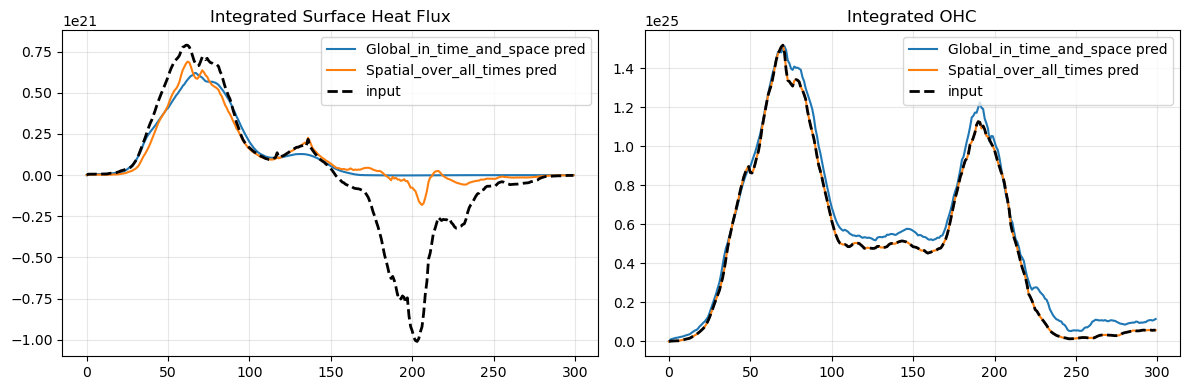

In [21]:
# Plot integrated timeseries: one observed curve plus one prediction per mode.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for mode in NORMALISATION_MODES:
    axes[0].plot(integrated_series_by_mode[mode]["SFX_pred_J"], label=f"{mode} pred")
    axes[1].plot(integrated_series_by_mode[mode]["OHC_pred_J"], label=f"{mode} pred")

# Observed input is mode-independent (same physical reference sample), so plot once.
reference_mode = NORMALISATION_MODES[0]
axes[0].plot(integrated_series_by_mode[reference_mode]["SFX_in_J"], "k--", linewidth=2, label="input")
axes[1].plot(integrated_series_by_mode[reference_mode]["OHC_in_J"], "k--", linewidth=2, label="input")

axes[0].set_title("Integrated Surface Heat Flux")
axes[1].set_title("Integrated OHC")
for ax in axes:
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


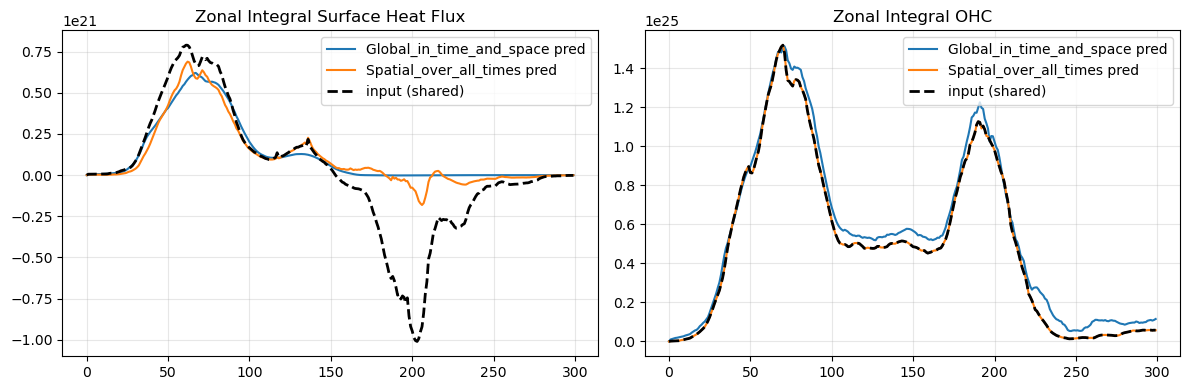

In [22]:
# Zonal integral comparison with shared canonical input (mode-independent truth).
# Integrate over longitude with ocean-only area weighting.

ocean_mask = mask.astype(bool)
area_weighted = np.where(ocean_mask, area_t, np.nan)
reference_mode = NORMALISATION_MODES[0]
obs_ref = input_display_by_mode[reference_mode]

zonal_by_mode = {}
for mode in NORMALISATION_MODES:
    pred = prediction_display_by_mode[mode]
    zonal_by_mode[mode] = {
        "OHC_pred": np.nansum(pred[0, 0] * area_weighted, axis=1),
        "SFX_pred": np.nansum(pred[0, 1] * area_weighted * 30 * 24 * 3600, axis=1),
    }

zonal_input = {
    "OHC_in": np.nansum(obs_ref[0, 0] * area_weighted, axis=1),
    "SFX_in": np.nansum(obs_ref[0, 1] * area_weighted * 30 * 24 * 3600, axis=1),
}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for mode in NORMALISATION_MODES:
    axes[0].plot(zonal_by_mode[mode]["SFX_pred"], label=f"{mode} pred")
    axes[1].plot(zonal_by_mode[mode]["OHC_pred"], label=f"{mode} pred")

axes[0].plot(zonal_input["SFX_in"], "k--", linewidth=2, label="input (shared)")
axes[1].plot(zonal_input["OHC_in"], "k--", linewidth=2, label="input (shared)")

axes[0].set_title("Zonal Integral Surface Heat Flux")
axes[1].set_title("Zonal Integral OHC")
for ax in axes:
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

